In [ ]:
!pip install -q tensorflow groq tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 3.2 MB/s eta 0:00:00


In [ ]:
import os
import time
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from groq import Groq
from tqdm import tqdm


In [ ]:
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")


In [ ]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 64
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 3e-4
BATCH_SIZE = 32
EPOCHS = 5
TEACHER_SAMPLES = 300


In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(seq):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in seq])


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN)
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN)


In [ ]:
client = Groq(api_key=GROQ_API_KEY)


In [ ]:
def groq_label(text):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": "Reply ONLY with 1 for positive or 0 for negative."},
            {"role": "user", "content": text}
        ],
        temperature=0
    )
    return int(response.choices[0].message.content.strip())


In [ ]:
teacher_labels = []

for i in tqdm(range(TEACHER_SAMPLES), desc="Labeling with Groq", unit="review"):
    review_text = decode_review(x_train[i])
    teacher_labels.append(groq_label(review_text))
    time.sleep(0.3)  # rate limit safety

teacher_labels = np.array(teacher_labels)


Labeling with Groq: 100%|██████████| 300/300 [14:54<00:00,  2.98s/review]


In [ ]:
x_distill = np.concatenate([
    x_train_pad[:TEACHER_SAMPLES],
    x_train_pad[TEACHER_SAMPLES:TEACHER_SAMPLES * 2]
])

y_distill = np.concatenate([
    teacher_labels,
    y_train[TEACHER_SAMPLES:TEACHER_SAMPLES * 2]
])


In [ ]:
def build_student():
    model = models.Sequential([
        layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        layers.SpatialDropout1D(DROPOUT_RATE),
        layers.Bidirectional(
            layers.LSTM(
                LSTM_UNITS,
                dropout=DROPOUT_RATE,
                recurrent_dropout=0.15
            )
        ),
        layers.Dense(32, activation="relu"),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )
    return model


In [ ]:
model = build_student()

model.fit(
    x_distill,
    y_distill,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 776ms/step - accuracy: 0.4501 - loss: 0.6947 - val_accuracy: 0.4250 - val_loss: 0.6941
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 760ms/step - accuracy: 0.5029 - loss: 0.6932 - val_accuracy: 0.5333 - val_loss: 0.6927
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 729ms/step - accuracy: 0.5571 - loss: 0.6910 - val_accuracy: 0.5333 - val_loss: 0.6918
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 737ms/step - accuracy: 0.5517 - loss: 0.6889 - val_accuracy: 0.5333 - val_loss: 0.6906
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 736ms/step - accuracy: 0.5499 - loss: 0.6857 - val_accuracy: 0.5333 - val_loss: 0.6898


In [ ]:
model.fit(
    x_train_pad[:10000],
    y_train[:10000],
    batch_size=32,
    epochs=2,
    verbose=1
)


Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.5964 - loss: 0.6677
Epoch 2/2
 42/313 ━━━━━━━━━━━━━━━━━━━━ 5:01 1s/step - accuracy: 0.8064 - loss: 0.4601

KeyboardInterrupt: 

In [ ]:
idx = 42
raw = decode_review(x_test[idx])

# LSTM prediction
lstm_pred = model.predict(
    x_test_pad[idx:idx+1],
    verbose=0
)[0][0]

# Groq prediction
groq_pred = groq_label(raw)

print(raw[:120], "...\n")
print("LSTM:", "Positive" if lstm_pred > 0.5 else "Negative", round(lstm_pred, 3))
print("Groq:", "Positive" if groq_pred == 1 else "Negative")


? having been a godzilla fan for many years gamera was to me a cheap ? to capitalize on the success of ? 1 ? star attack ...

LSTM: Negative 0.066
Groq: Positive


In [ ]:
indices = random.sample(range(len(x_test)), 30)

true_labels = []
groq_labels = []
lstm_labels = []

groq_cache = {}

for idx in indices:
    text = decode_review(x_test[idx])
    true_labels.append(y_test[idx])

    # Cache Groq predictions
    if idx not in groq_cache:
        groq_cache[idx] = groq_label(text)
    groq_labels.append(groq_cache[idx])

    pred = model.predict(
        x_test_pad[idx:idx+1],
        verbose=0
    )[0][0]

    lstm_labels.append(1 if pred > 0.5 else 0)

true_labels = np.array(true_labels)
groq_labels = np.array(groq_labels)
lstm_labels = np.array(lstm_labels)

groq_accuracy = np.mean(groq_labels == true_labels)
lstm_accuracy = np.mean(lstm_labels == true_labels)

print("Groq accuracy:", groq_accuracy)
print("LSTM accuracy:", lstm_accuracy)


Groq accuracy: 0.9333333333333333
LSTM accuracy: 0.7666666666666667


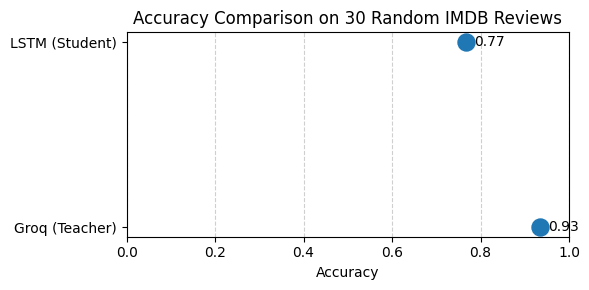

In [ ]:
plt.figure(figsize=(6, 3))

y_pos = range(len(labels))
plt.scatter(accuracies, y_pos, s=150)
plt.yticks(y_pos, labels)
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Accuracy Comparison on 30 Random IMDB Reviews")

for i, acc in enumerate(accuracies):
    plt.text(acc + 0.02, i, f"{acc:.2f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
model.save("distilled_lstm_sentiment.h5")


In [ ]:
model = tf.keras.models.load_model("distilled_lstm_sentiment.h5")
